In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf


In [3]:
start = '2012-01-12'
end = '2022-12-21'
stock = 'GOOGL'
data = yf.download(stock, start, end)

[*********************100%***********************]  1 of 1 completed


In [4]:
data.reset_index(inplace = True)

In [5]:
data

,Date,Open,High,Low,Close,Adj Close,Volume
0,2012-01-12,15.796296,15.838088,15.678178,15.756757,15.717836,74932992
1,2012-01-13,15.672172,15.689439,15.542042,15.640390,15.601758,92199708
2,2012-01-17,15.815315,15.815315,15.657658,15.730230,15.691376,76295628
3,2012-01-18,15.681431,15.865866,15.568569,15.838589,15.799466,110357532
4,2012-01-19,16.040791,16.040791,15.802302,16.005255,15.965721,251959788
...,...,...,...,...,...,...,...
2749,2022-12-14,95.199997,96.870003,93.599998,95.070000,94.835175,28733600
2750,2022-12-15,93.129997,93.639999,90.010002,90.860001,90.635574,40107000
2751,2022-12-16,90.760002,91.330002,89.519997,90.260002,90.037056,58011800
2752,2022-12-19,90.260002,90.559998,88.209999,88.440002,88.221550,29493000


In [6]:
ma_100_days = data.Close.rolling(100).mean()

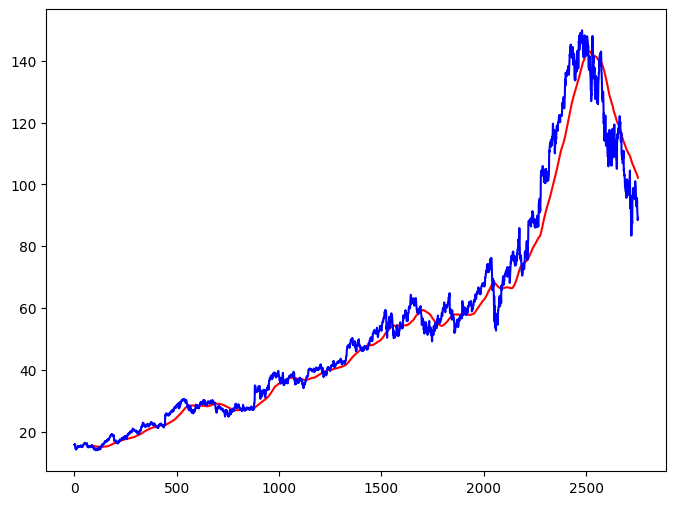

In [7]:
plt.figure(figsize =(8, 6))
plt.plot(ma_100_days, 'r')
plt.plot(data.Close, 'b')
plt.show()

In [8]:
ma_200_days = data.Close.rolling(200).mean()

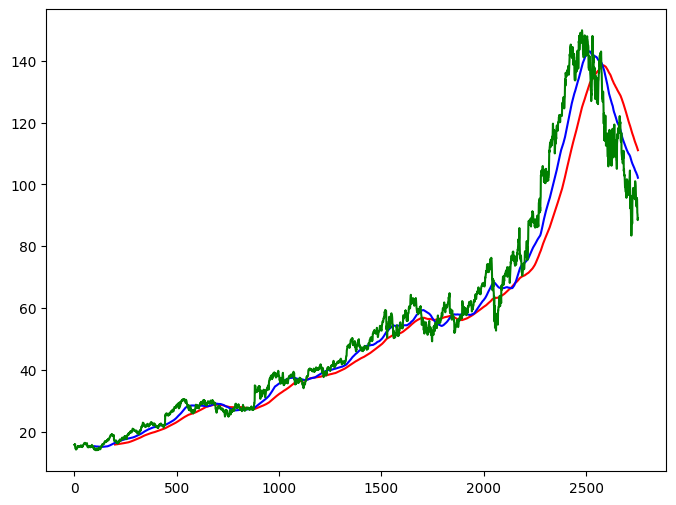

In [9]:
plt.figure(figsize=(8,6))
plt.plot(ma_200_days, 'r')
plt.plot(ma_100_days,'b')
plt.plot(data.Close,'g')

In [10]:
data.dropna(inplace=True)

In [11]:
data_train = pd.DataFrame(data.Close[0: int(len(data)*0.8)])
data_test = pd.DataFrame(data.Close[int(len(data)*0.8): len(data)])

In [12]:
data_train.shape[0], data_test.shape[0]

(2203, 551)

In [13]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0,1))

In [14]:
data_train_scale = scaler.fit_transform(data_train)

In [15]:
x = []
y = []

for i in range(100, data_train_scale.shape[0]):
    x.append(data_train_scale[i-100:i])
    y.append(data_train_scale[i, 0])
    


In [16]:
x, y = np.array(x), np.array(y)

In [17]:
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [18]:
model = Sequential()

model.add(LSTM(units = 50, activation = 'relu', reutrn_sequences = True,
               input_shape = ((x.shape[1], 1))))
model.add(Dropout(0.20))
          
model.add(LSTM(units = 60, activation = 'relu', reutrn_sequences = True))
model.add(Droupout(0.3))

model.add(LSTM(units = 80, activation = 'relu', return_sequences = True))
model.add(Droupout(0.4))

model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units = 1))
          

c:\Users\BBhuwan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


ValueError: Unrecognized keyword arguments passed to LSTM: {'reutrn_sequences': True}